# PLSA
_Probabilistic latent semantic analysis_

## Preliminaries
#### Import dependencies

In [25]:
import sys
import matplotlib.pyplot as plt # type: ignore

#### Set the plotting environment

In [26]:
%matplotlib inline

#### Put the actual `plsa` package onto the _python path_

In [27]:
#sys.path.append('/Users/leo/stagear/clustering/PLSA/plsa')

#### Import main classes from the `plsa` package

In [28]:
from plsa import Corpus, Pipeline, Visualize, preprocessors
from plsa.pipeline import DEFAULT_PIPELINE
from plsa.algorithms import PLSA

## Data Sources
As they can be quite large, no actual text corpus is included with the `plsa` package. Two nice examples to play with could be
- [Economic News Article Tone and Relevance](https://www.figure-eight.com/data-for-everyone/)
- [Blog Authorship Corpus](http://u.cs.biu.ac.il/~koppel/BlogCorpus.htm)
We are assuming here that you have downloaded one of them (or both) and placed them under a `data` folder under the
root of your clone of the `PLSA` [GitHub repository](https://github.com/yedivanseven/PLSA).

In [29]:
csv_file = '/Users/leo/stagear/corpus/laprison_lemma.csv'
#directory = '../data/blogs'

## Set Up the Corpus
#### Define pre-processing pipeline
Depending on there source, actual, real-world text documents are "dirty", and need to be "cleaned up" through a series of pre-processing steps. The `plsa` submodule `preprocessors` contains several of them
(see the [API documentation](https://probabilistic-latent-semantic-analysis.readthedocs.io/en/latest/plsa.preprocessors.html)). For convenience, they are assembled into a default pipeline that should help you to get
some results out-of-the-box.

In [30]:
stopword_path = "../corpus/stopwords.txt"

with open(stopword_path, "r") as f:
    stopwords = f.readlines()

stopwords_processed = []
for word in stopwords:
    stopwords_processed.append(word.strip())

type(stopwords)
print(stopwords_processed)

['m', ',', 'de', 'le', 'que', 'un', 'être', '.', 'avoir', 'à', 'je', 'ne', 'ce', 'et', 'lui', 'il', 'pas', 'qui', 'en', 'son', 'me', 'se', 'pour', 'dans', 'faire', 'plus', 'mais', '«', 'dire', '»', 'tout', 'nous', 'mon', 'si', 'par', 'pouvoir', 'vous', 'comme', 'on', 'luire', 'au', 'avec', 'même', 'Albertine', 'où', 'moi', 'bien', 'voir', 'autre', 'sur', 'y', 'savoir', 'sans', 'ou', ':', 'aller', '', '', 'celui', 'quand', ';', 'celer', 'vouloir', '-', 'm.', 'quelque', 'chez', 'aussi', 'Charlus', 'chose', '?', 'dont', 'venir', 'mme', 'croire', 'car', '!', '(', 'jour', 'femme', 'Verdurin', 'vie', 'parler', ')', 'jamais', 'petit', 'donner', 'notre', 'peu', 'connaître', 'encore', 'grand', 'aimer', 'non', 'trouver', 'peut-être', '--', 'moins', 'devoir', 'rien', 'temps', 'seul', 'air', 'jeune', 'personne', 'fois', 'sembler', 'prendre', 'Morel', 'moment', 'demander', 'certain', 'entrer', 'passer', 'lequel', 'tel', 'heure', 'parce', 'deux', 'penser', '_', 'monde', 'seulement', 'toujours', 'tan

In [31]:
import string

pipeline = Pipeline(*DEFAULT_PIPELINE)
print(pipeline)
stopwords = stopwords_processed

pipeline = Pipeline(preprocessors.to_lower, preprocessors.remove_numbers, preprocessors.remove_punctuation(string.punctuation), preprocessors.tokenize, preprocessors.RemoveStopwords(stopwords))

#pipeline = Pipeline(preprocessors.remove_non_ascii, preprocessors.to_lower, preprocessors.remove_numbers, preprocessors.remove_punctuation, preprocessors.tokenize)
print(pipeline)

Pipeline:
0: remove_non_ascii
1: to_lower
2: remove_numbers
3: tag_remover
4: punctuation_remover
5: tokenize
6: LemmatizeWords
7: RemoveStopwords
8: short_word_remover
Pipeline:
0: to_lower
1: remove_numbers
2: punctuation_remover
3: tokenize
4: RemoveStopwords


#### Load corpus
Execute either this cell ...

In [32]:
corpus = Corpus.from_csv(csv_file, pipeline, encoding='utf-8', max_docs=1000)

corpus

Corpus:
Number of documents: 427
Number of words:     8189

## Run PLSA

#### Choose the number of topics

In [33]:
n_topics = 30

#### Instantiate a PLSA model

In [34]:
plsa = PLSA(corpus, n_topics, True)
plsa

PLSA:
====
Number of topics:     30
Number of documents:  427
Number of words:      8189
Number of iterations: 0

Notice that we did not do any iterations yet.

In [49]:
from scikitlearn  

SyntaxError: invalid syntax (2767572723.py, line 1)

#### Fit a PLSA model

In [35]:
result = plsa.fit(max_iter=80)
plsa

PLSA:
====
Number of topics:     30
Number of documents:  427
Number of words:      8189
Number of iterations: 72

Now we indeed did do some iterations.

#### Find the best PLSA model of many
As with any iterative algorithm, also the probabilities in PSLA need to be (randomly) initialized prior to the first iteration step. Therefore, calling the ``fit`` method of two different `PLSA` instances operating on the _same_ corpus with the _same_ number of topics potentially leads to (slightly) different results, corresponding to different local minima of the Kullback-Leibler divergence between the true document-word probability and its approximate factorization. To mitigate this effect, perform multiple runs and pick the best model.

Be patient, this may take a while ...

In [36]:
#result = plsa.best_of(5)

#### Examine the results
Feel free to explore the attributes of the `result` object. See the [API documentation](https://probabilistic-latent-semantic-analysis.readthedocs.io/en/latest/plsa.algorithms.result.html) for more information.

For example, we could see the relative prevalence of the individual topics we found.

In [37]:
result.topic

array([0.05530135, 0.04781   , 0.04745985, 0.0415118 , 0.04008083,
       0.03958161, 0.03925676, 0.03906255, 0.03810302, 0.03427558,
       0.03361051, 0.03270134, 0.0326796 , 0.0324149 , 0.0318143 ,
       0.03174829, 0.03170575, 0.03069195, 0.02982032, 0.02941553,
       0.0292892 , 0.02854587, 0.02813211, 0.02800611, 0.02764342,
       0.02720944, 0.02696704, 0.02594935, 0.01969753, 0.01951408])

And, of course, we can look at individual topics, that is, how important which word is for which topic. Let's look at the top-10 words of the first topic.

In [38]:
result.word_given_topic[0][:10] 

(('brichot', 0.006536195773381856),
 ('villeparisis', 0.005776995115378819),
 ('baron', 0.003915009541944529),
 ('saintine', 0.003631207417739133),
 ('réputation', 0.0035690633701129766),
 ('nom', 0.0030717526606730866),
 ('swann', 0.0029712037885628955),
 ('affaire', 0.0028475259256572688),
 ('dreyfus', 0.0028000860906001943),
 ('gens', 0.002646795029308961))

In [39]:
result.word_given_topic[12][:50] 

(('moquer', 0.0034755285076882108),
 ('sonate', 0.0033872246784759173),
 ('parfois', 0.00325691356424586),
 ('capuchon', 0.003072416162365446),
 ('mesure', 0.0030458907802906067),
 ('repos', 0.0030198371208843174),
 ('tête', 0.0026834297483889435),
 ('intelligent', 0.0026770356921944527),
 ('ramener', 0.002585204395766726),
 ('tristan', 0.002515124678220561),
 ('inquiétude', 0.0025073791311370688),
 ('visage', 0.002454366069130459),
 ('souffrance', 0.0024543660672104385),
 ('gêner', 0.0024158681609367373),
 ('mot', 0.0023873090972148818),
 ('lire', 0.002387084051278004),
 ('fait', 0.002370932108760644),
 ('doute', 0.002327860787604054),
 ('là', 0.0023091916404601883),
 ('complet', 0.002264943214168946),
 ('livre', 0.002251003326322107),
 ('esprit', 0.002242793165900967),
 ('brichot', 0.002217437308915036),
 ('soleil', 0.002215001129747072),
 ('profond', 0.002205428416935027),
 ('guermantes', 0.0021953419423405354),
 ('garder', 0.0021759396967704473),
 ('quasi', 0.002163512899461557),
 

## Visualize the Results

In [40]:
visualize = Visualize(result)
visualize

Visualize:
Number of topics:    30
Number of documents: 427
Number of words:     8189

#### Convergence
Since PLSA uses an iterative expectation-maximization (EM) style algorithm, let's make sure we have achieved reasonable convergence.

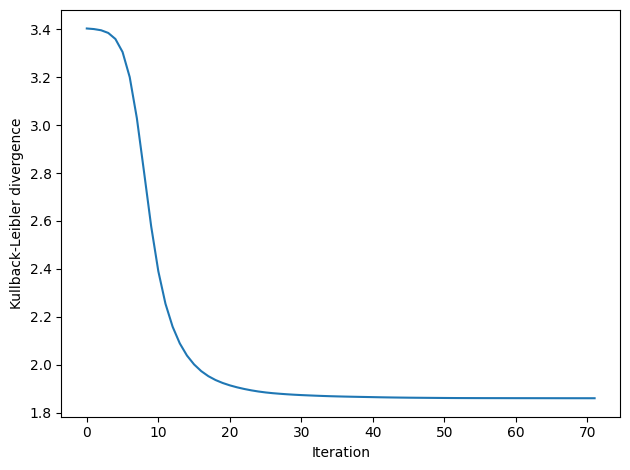

In [41]:
fig, ax = plt.subplots()
_ = visualize.convergence(ax)
fig.tight_layout()

#### Relative topic importance
How important are the topics we found in the corpus?

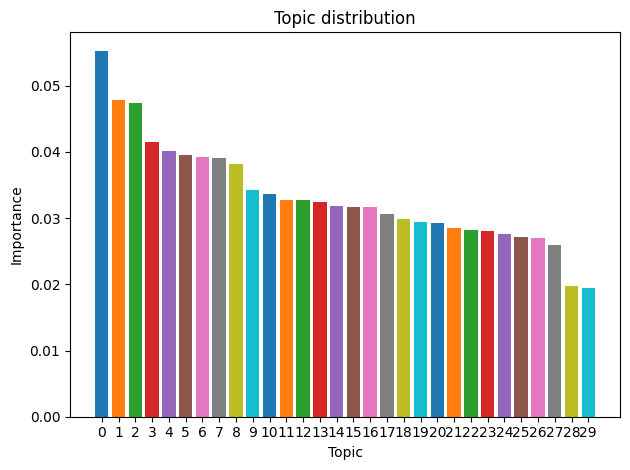

In [42]:
fig, ax = plt.subplots()
_ = visualize.topics(ax)
fig.tight_layout()

#### The topics
The most interesting part is probably the topics themselves, We can visualize them as word clouds.

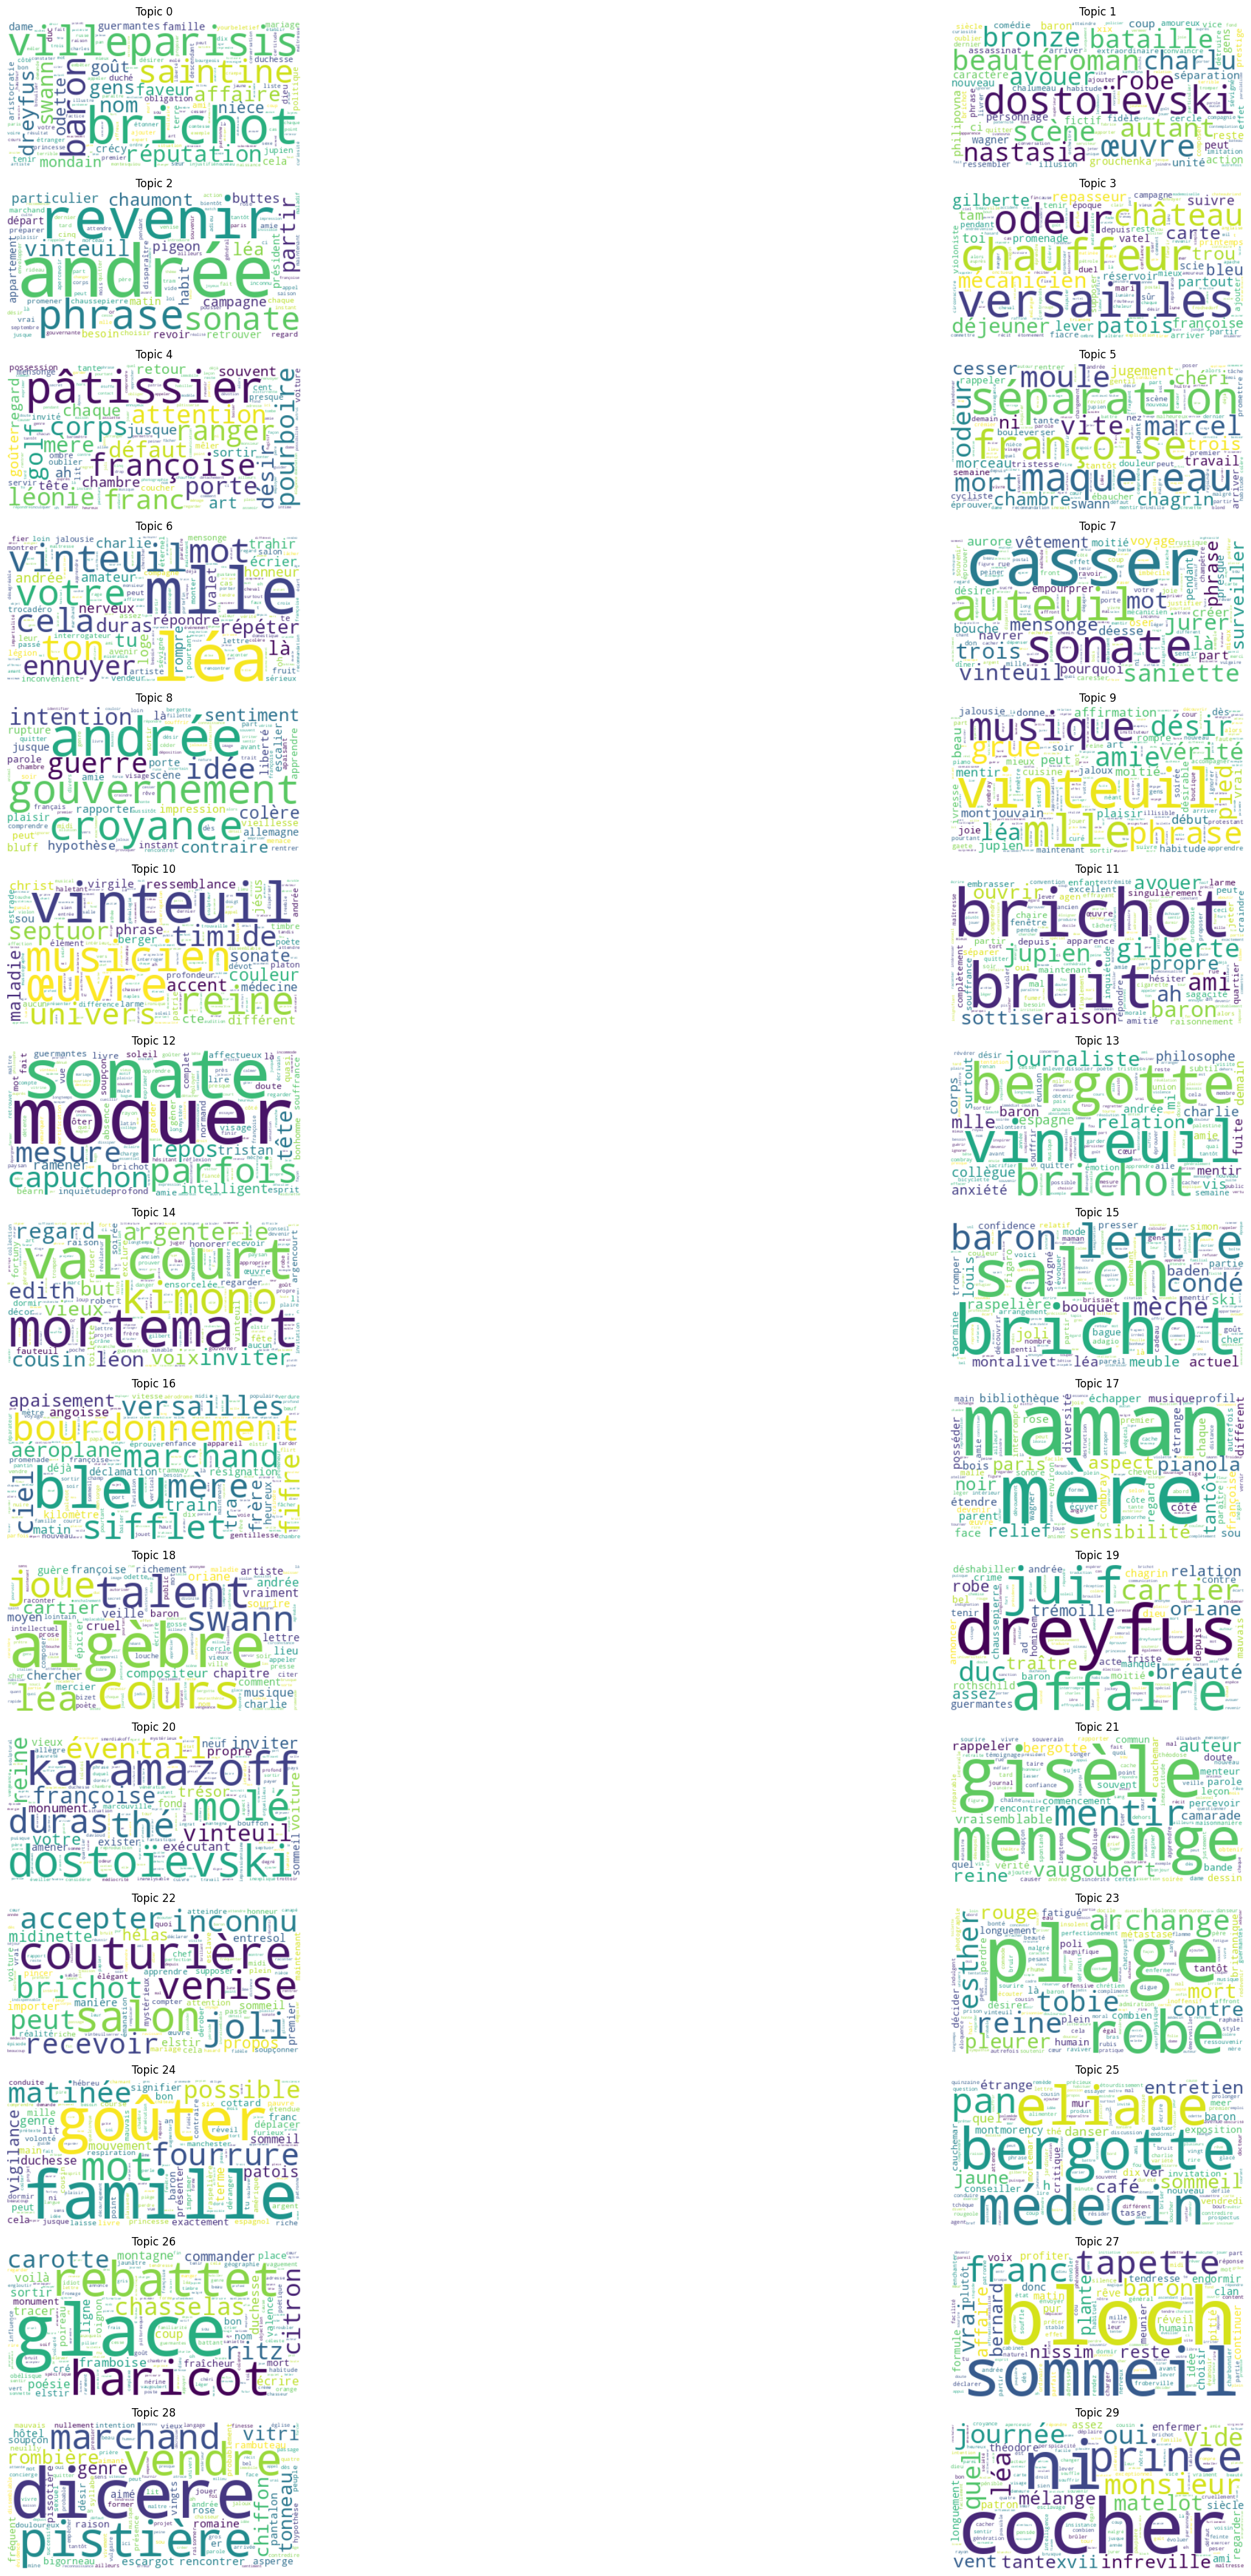

In [43]:
fig = plt.figure(figsize=(40, 40))
_ = visualize.wordclouds(fig)

#### Relative topic importance in a document
Also interesting is the mixture of topics in each document. Let's look at the first one.

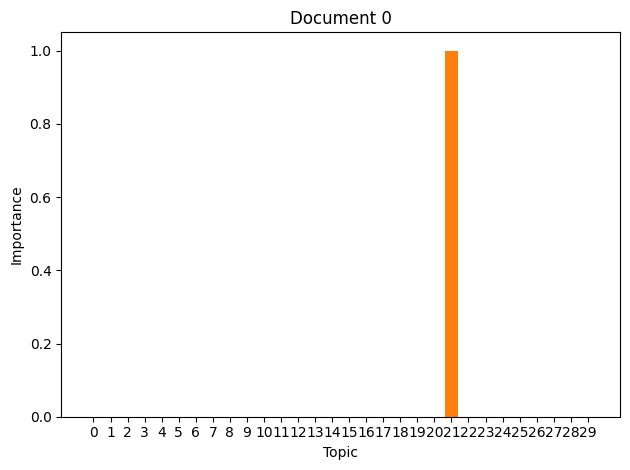

In [44]:
fig, ax = plt.subplots()
_ = visualize.topics_in_doc(0, ax)
fig.tight_layout()

Let's compare this with what the prediction would look like, pretending that this document wasn't seen before.

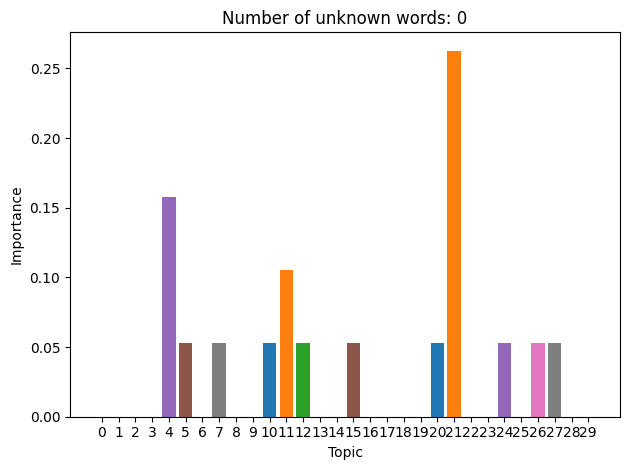

In [45]:
for first in corpus.raw:
    if first:
        break
        
fig, ax = plt.subplots()
_ = visualize.prediction(first, ax)
fig.tight_layout()

Similar, but not quite the same. This is the very nature of matrix factorization algorithms, to which PLSA can be seen to belong. We try to approxmiate the original counts of each word in each document with a lower-dimensional representation of the data. That's why the topic composition get's somewhat "blurred".

#### Prediction for a new document
We can also visualize the predicited topic composition for a new document.

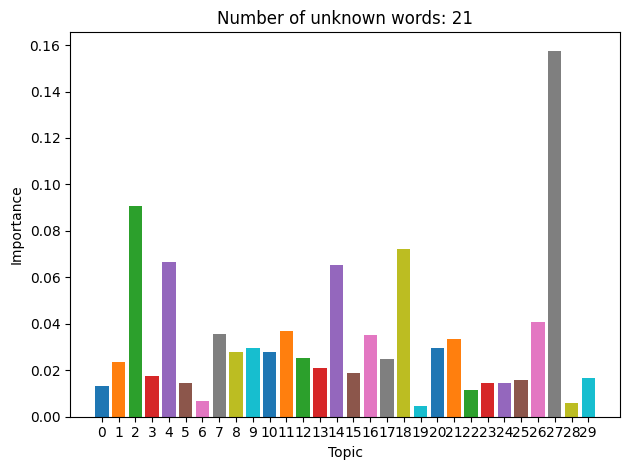

In [46]:
new_doc = "Les cloisons , qui séparaient nos deux cabinets de toilette ( celui d' Albertine tout pareil était une salle de bains que maman , en ayant une autre dans la partie opposée de l' appartement , n' avait jamais utilisée pour ne pas me faire de bruit ) , étaient si minces que nous pouvions parler tout en nous lavant chacun dans le nôtre , poursuivant une causerie qu' interrompait seulement le bruit de l' eau , dans cette intimité que permet souvent à l' hôtel l' exiguïté du logement et le rapprochement des pièces mais qui , à Paris , est si rare ."

fig, ax = plt.subplots()
_ = visualize.prediction(new_doc, ax)
fig.tight_layout()

In [47]:
for i in range(0, 19):
    visualize.words_in_topic(i, plt.axes._subplots.AxesSubplot)

AttributeError: 'function' object has no attribute '_subplots'

In [120]:
corpus.raw[21]

'physiquement , lui avoir changer aussi . son long oeil bleu -- plus allongé -- ne avoir pas garder le même forme ; il avoir bien le même couleur , mais sembler être passer à le état liquide . si bien que , quand lui le fermer , ce être comme quand avec un rideau on empêcher de voir le mer . ce être sans doute de ce partie de lui-même que je me souvenir surtout , chaque nuit en le quitter . car , par exemple , tout au contraire chaque matin , le crêpelage de son cheveu me causer longtemps le même surprise , comme un chose nouveau que je ne avoir jamais voir . et pourtant , au-dessus de regard souriant de un jeune fille , que y avoir -t il de plus beau que ce couronne boucler de violette noir . le sourire proposer plus de amitié ; mais le petit crochet vernir de cheveu en fleur , plus parent de le chair dont il sembler le transposition en vaguelette , attraper davantage le désir . \n'

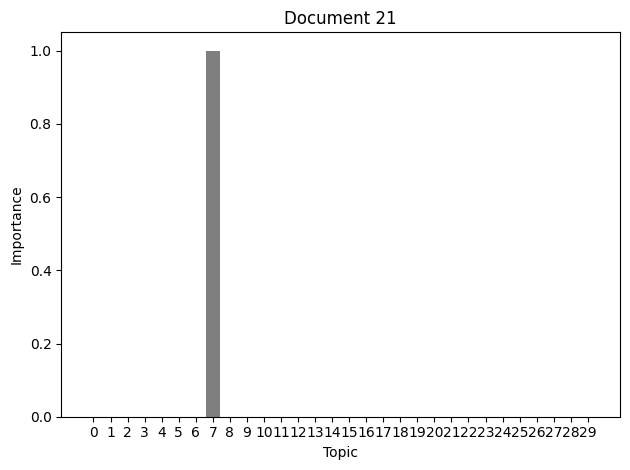

In [114]:
fig, ax = plt.subplots()
_ = visualize.topics_in_doc(21, ax)
fig.tight_layout()

IndexError: index 2110 is out of bounds for axis 0 with size 427

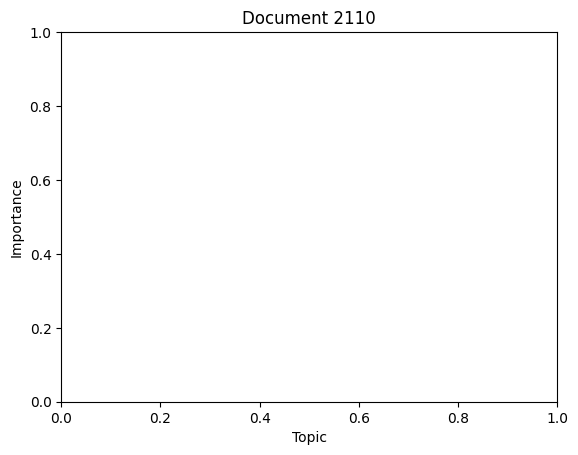

In [77]:
fig, ax = plt.subplots()
_ = visualize.topics_in_doc(2110, ax)
fig.tight_layout()

In [ ]:
fig, ax = plt.subplots()
_ = visualize.topics_in_doc(2113, ax)
fig.tight_layout()